In [2]:
import torch
from torch import nn

from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np

from typing import Tuple, List, Optional
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime



import lightning as pl


from Models.models import Siren, Finer
from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation
from test3D import visualize_volume_slices
import copy

In [3]:
config = copy.deepcopy(default_config)
config["in_features"] = 3
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)

lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
print('gt_image loaded')

Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]
             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634.

In [4]:
type(lf_gt), lf_gt.shape, gt_image.shape, type(gt_image), lf_gt.dtype, gt_image.dtype

(torch.Tensor,
 torch.Size([87, 96, 192, 1]),
 torch.Size([174, 192, 192, 1]),
 torch.Tensor,
 torch.float32,
 torch.float32)

In [182]:
lf_gt.max(), lf_gt.min(), gt_image.max(), gt_image.min()

(tensor(1.), tensor(0.), tensor(1.), tensor(0.))

randompoints for unsupervised setup

In [332]:
class RandomPointsDataset(Dataset):
    def __init__(self, image: torch.Tensor, lf_image:torch.Tensor, points_num: int = POINTS_PER_SAMPLE):
        super().__init__()
        self.device = 'cpu' #get_device()
        self.points_num = points_num
        assert image.dtype == torch.float32
        assert lf_image.dtype == torch.float32
        self.image = image.to(self.device)  # (H, W, ..., C)
        self.lf_image = lf_image.to(self.device)  # (H, W, ..., C)
        # self.dim_sizes = self.image.shape[:-1]  # Size of each spatial dimension
        self.dim_sizes = self.lf_image.shape[:-1]  # Size of each spatial dimension
        

        # To help us define the input/output sizes of our network later
        # we store the size of our input coordinates and output values
        self.coord_size = len(self.image.shape[:-1])  # Number of spatial dimensions
        self.value_size = self.lf_image.shape[-1]  # Channel size
        # self.value_size = self.lf_image.shape[-1]  # Channel size

    def __len__(self):
        return 1

    # def __getitem__(self, idx: int):
    #     # Create random sample of pixel indices
    #     point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]
    #     # point_indices = [i.to(torch.int32) for i in point_indices]
    #     # point_indices = [i.to('cpu') for i in point_indices]
    #     # print(point_indices[0].dtype, point_indices[0].device)
        
    #     point_indices_lf = [(F.interpolate(i.unsqueeze(0).unsqueeze(0).to(torch.float32), scale_factor=0.25)).squeeze(0).squeeze(0) for i in point_indices]
    #     point_indices = [i.to(torch.int64) for i in point_indices]
    #     point_indices_lf = [i.to(torch.int64) for i in point_indices_lf]

    #     print(point_indices[0], point_indices_lf[0])
    #     # Retrieve image values from selected indices
    #     point_values = self.image[tuple(point_indices)]
    #     print(self.image.shape, point_values.shape, self.lf_image.shape)
    #     point_values_lf = self.lf_image[tuple(point_indices_lf)]
    #     # print(point_values.shape, point_values_lf.shape)
        
    #     # Convert point indices into normalized [-1.0, 1.0] coordinates
    #     point_coords = torch.stack(point_indices, dim=-1)
    #     spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
    #     point_coords_norm = point_coords / (spatial_dims / 2) - 1

    #     # The subject index is also returned in case the user wants to use subject-wise learned latents
    #     return point_coords_norm, point_values#, point_values_lf

    def __getitem__(self, idx: int):
        # # Create random sample of pixel indices
        
        point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]
        print(point_indices[0].shape)
        # Retrieve image values from selected indices
        point_values = self.lf_image[tuple(point_indices)]
        print(point_values.shape)
        point_values = F.interpolate(point_values.unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0).squeeze(0)
        print(point_values.shape)
        # Convert point indices into normalized [-1.0, 1.0] coordinates
        point_coords = torch.stack(point_indices, dim=-1)
        spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
        point_coords_norm = point_coords / (spatial_dims / 2) - 1

        # The subject index is also returned in case the user wants to use subject-wise learned latents
        return point_coords_norm, point_values
        


torch.Size([36864])
torch.Size([36864, 1])
torch.Size([9216])


randompoints for simultaneous unsupervised and segmentation setup

In [339]:
lf_gt_seg_dice.shape

torch.Size([1, 4, 87, 96, 192])

In [358]:
class RandomPointsDataset(Dataset):
    def __init__(self, image: torch.Tensor, lf_image:torch.Tensor, lf_gt_seg_dice:torch.Tensor, points_num: int = POINTS_PER_SAMPLE):
        super().__init__()
        self.device = 'cpu' #get_device()
        self.points_num = points_num
        assert image.dtype == torch.float32
        assert lf_image.dtype == torch.float32
        self.image = image.to(self.device)  # (H, W, ..., C)
        self.lf_image = lf_image.to(self.device)  # (H, W, ..., C)
        self.lf_gt_seg_dice = lf_gt_seg_dice.permute(1,2,3,4,0).to(self.device) #(tissues, H,W,D, C)
        # self.dim_sizes = self.image.shape[:-1]  # Size of each spatial dimension
        self.dim_sizes = self.lf_image.shape[:-1]  # Size of each spatial dimension
        

        # To help us define the input/output sizes of our network later
        # we store the size of our input coordinates and output values
        self.coord_size = len(self.image.shape[:-1])  # Number of spatial dimensions
        self.value_size = self.lf_image.shape[-1]  # Channel size
        # self.value_size = self.lf_image.shape[-1]  # Channel size

    def __len__(self):
        return 1


    def __getitem__(self, idx: int):
        # # Create random sample of pixel indices
        
        point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]
        # print(point_indices[0].shape)
        # Retrieve image values from selected indices
        point_values = self.lf_image[tuple(point_indices)]

        point_values_seg = [self.lf_gt_seg_dice[i][tuple(point_indices)] for i in range(self.lf_gt_seg_dice.shape[0])]
        point_values_seg = torch.stack(point_values_seg,axis = 0)
        # print(point_values.shape, point_values_seg.shape)
        point_values = F.interpolate(point_values.unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0).squeeze(0) #downsampling lf_gt
        point_values_seg = [F.interpolate(point_values_seg[i].unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0).squeeze(0) for i in range(self.lf_gt_seg_dice.shape[0])] #downsampling lf_gt_seg
        point_values_seg = torch.stack(point_values_seg,axis = 0)
        # print(point_values.shape, point_values_seg.shape)

        # Convert point indices into normalized [-1.0, 1.0] coordinates
        point_coords = torch.stack(point_indices, dim=-1)
        spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
        point_coords_norm = point_coords / (spatial_dims / 2) - 1

        # The subject index is also returned in case the user wants to use subject-wise learned latents
        return point_coords_norm, point_values
        
POINTS_PER_SAMPLE = 96*96*4
dataset = RandomPointsDataset(gt_image, lf_gt, lf_gt_seg_dice, points_num=POINTS_PER_SAMPLE)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=False) # We set a batch_size of 1 since our dataloader is already returning a batch of points.
temp = next(iter(dataloader))


In [367]:
dataset.coord_size, dataset.value_size

(3, 1)

In [351]:
lf_gt_seg_dice.shape[1]
for i in range()
    

4

In [366]:
class MyModule(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(10, 10) for i in range(10)])

    def forward(self, x):
        # ModuleList can act as an iterable, or be indexed using ints
        for i, l in enumerate(self.linears[:-1]):
            print(i, l)
            x = self.linears[i // 2](x) + l(x)
        t1 = x[0]
        t2 = x[1:]

        return t1, t2

temp1 = MyModule()
x = torch.randn(10, 10 )
op1, op2 = temp1.forward(x)
op1.shape, op2.shape

0 Linear(in_features=10, out_features=10, bias=True)
1 Linear(in_features=10, out_features=10, bias=True)
2 Linear(in_features=10, out_features=10, bias=True)
3 Linear(in_features=10, out_features=10, bias=True)
4 Linear(in_features=10, out_features=10, bias=True)
5 Linear(in_features=10, out_features=10, bias=True)
6 Linear(in_features=10, out_features=10, bias=True)
7 Linear(in_features=10, out_features=10, bias=True)
8 Linear(in_features=10, out_features=10, bias=True)


(torch.Size([10]), torch.Size([9, 10]))

In [395]:
class RandomPointsDataset(Dataset):
    def __init__(self, image: torch.Tensor, lf_image:torch.Tensor, lf_gt_seg_dice:torch.Tensor, points_num: int = POINTS_PER_SAMPLE):
        super().__init__()
        self.device = 'cpu' #get_device()
        self.points_num = points_num
        assert image.dtype == torch.float32
        assert lf_image.dtype == torch.float32
        self.image = image.to(self.device)  # (H, W, ..., C)
        self.lf_image = lf_image.to(self.device)  # (H, W, ..., C)
        self.lf_gt_seg_dice = lf_gt_seg_dice.permute(1,2,3,4,0).to(self.device) #(tissues, H,W,D, C)
        # self.dim_sizes = self.image.shape[:-1]  # Size of each spatial dimension
        self.dim_sizes = self.lf_image.shape[:-1]  # Size of each spatial dimension
        

        # To help us define the input/output sizes of our network later
        # we store the size of our input coordinates and output values
        self.coord_size = len(self.image.shape[:-1])  # Number of spatial dimensions
        self.value_size = self.lf_image.shape[-1]  # Channel size
        # self.value_size = self.lf_image.shape[-1]  # Channel size

    def __len__(self):
        return 1


    def __getitem__(self, idx: int):
        # # Create random sample of pixel indices
        
        point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]
        # print(point_indices[0].shape)
        # Retrieve image values from selected indices
        point_values = self.lf_image[tuple(point_indices)]

        point_values_seg = [self.lf_gt_seg_dice[i][tuple(point_indices)] for i in range(self.lf_gt_seg_dice.shape[0])]
        point_values_seg = torch.stack(point_values_seg,axis = 0)
        # print(point_values.shape, point_values_seg.shape)
        point_values = F.interpolate(point_values.unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0).squeeze(0) #downsampling lf_gt
        point_values_seg = [F.interpolate(point_values_seg[i].unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0).squeeze(0) for i in range(self.lf_gt_seg_dice.shape[0])] #downsampling lf_gt_seg
        point_values_seg = torch.stack(point_values_seg,axis = 0)
        # print(point_values.shape, point_values_seg.shape)

        # Convert point indices into normalized [-1.0, 1.0] coordinates
        point_coords = torch.stack(point_indices, dim=-1)
        spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
        point_coords_norm = point_coords / (spatial_dims / 2) - 1

        # The subject index is also returned in case the user wants to use subject-wise learned latents
        return point_coords_norm, point_values, point_values_seg

dataset = RandomPointsDataset(gt_image, lf_gt, lf_gt_seg_dice, points_num=POINTS_PER_SAMPLE)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=False) # We set a batch_size of 1 since our dataloader is already returning a batch of points.
    


In [398]:
POINTS_PER_SAMPLE = 96*96*4
lf_points_per_sample = 48*48*4
class ReLULayer(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 **kwargs):
        super().__init__()
        self.linear = nn.Linear(in_size, out_size, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)
        x = torch.relu(x)
        return x


class MLP(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 hidden_size: int = 128,
                 num_layers: int = 3,
                 layer_class: nn.Module = ReLULayer,
                 **kwargs):
        super().__init__()

        a = [layer_class(in_size, hidden_size, **kwargs)]
        for i in range(num_layers - 1):
            a.append(layer_class(hidden_size, hidden_size, **kwargs))
        
        # a.append(nn.Linear(hidden_size, 1)) #actual image
        a.append(nn.Linear(hidden_size, out_size)) #segmentations+image
        self.layers = nn.ModuleList(a)        
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=-1)
        print("MLP init. complete")

    def forward(self, x: torch.Tensor):
        for i, layer in enumerate(self.layers):
            x = layer(x)
        print("FW pass: hidden layers ")
        print(x.shape)
        output_image_pre = x[:,0] #output image before applying activation function
        output_seg_pre = x[:,1:] #output seg before applying activation function
        output_image = self.relu(output_image_pre)
        output_seg = self.softmax(output_seg_pre)
        print(output_image.shape, output_seg.shape)
        return output_image, output_seg


siren_inr = MLP(in_size = 3,
                out_size = 5, 
                hidden_size=32, num_layers=3,
                layer_class=ReLULayer, 
                siren_factor=30.0,
                )

temp_input, _,  _ = next(iter(dataloader))
temp_input = temp_input.view(-1, temp_input.shape[-1])
print(temp_input.shape)
temp_op = siren_inr(temp_input)

MLP init. complete
torch.Size([36864, 3])
FW pass: hidden layers 
torch.Size([36864, 5])
torch.Size([36864]) torch.Size([36864, 4])


In [394]:
temp_input.shape

torch.Size([36864, 3])

In [387]:
temp_op[0].shape, temp_op[1].shape

(torch.Size([1, 36864]), torch.Size([1, 36864, 4]))

In [400]:
from monai.losses.dice import *  # NOQA
import torch
from monai.losses.dice import DiceLoss
B, C, H, W, D = 7, 5, 3, 2, 5
input = torch.rand(B, C, H, W, D)

target_idx = torch.randint(low=0, high=C - 1, size=(B, H, W)).long()
target = one_hot(target_idx[:, None, ...], num_classes=C)
self = DiceLoss(reduction='none')
print(input.shape, target.shape)
loss = self(input, target)

torch.Size([7, 5, 3, 2, 5]) torch.Size([7, 5, 3, 2])


AssertionError: ground truth has different shape (torch.Size([7, 5, 3, 2])) from input (torch.Size([7, 5, 3, 2, 5]))

In [419]:
from kornia.losses import total_variation
a = torch.randn(36864)
total_variation(a.reshape(96,96,4), reduction='mean').mean()
print(total_variation(a.reshape(96,96,4), reduction='mean').mean())
print(total_variation(a.reshape(4,96,96), reduction='mean').mean())

In [424]:
a = [1,4,48,48,48]
a[2:]

[48, 48, 48]

In [25]:
import monai
dice_score2 = monai.metrics.GeneralizedDiceScore()# DiceMetric()

from torchmetrics.segmentation import GeneralizedDiceScore
dice_score = GeneralizedDiceScore(num_classes=4, per_class=True)

In [28]:

temp1 = torch.rand(1,  4, 87, 96, 192)
temp2 = torch.rand(1, 4, 87, 96, 192)
dice_score(temp1, temp2), dice_score2(temp1, temp2)

(tensor([0.5004, 0.5001, 0.5004, 0.5001]),
 tensor([[0.5004, 0.5001, 0.5004, 0.5001]]))

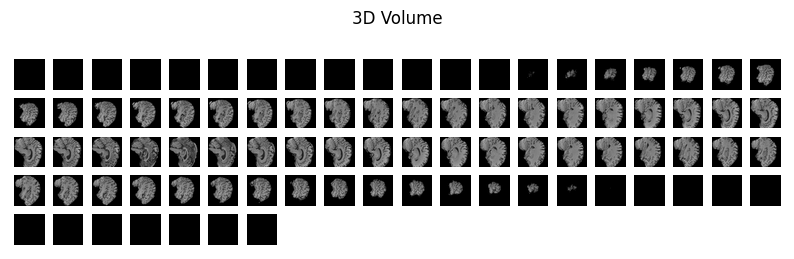

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from monai.visualize import matshow3d
# create a figure of a 3D volume
volume = np.random.rand(10, 10, 10)
fig = plt.figure()
matshow3d(gt_image[:,:,:,0], fig=fig, title="3D Volume", frames_per_row=20, every_n=2, interpolation ='lanczos',cmap='gray')
plt.show()
# create a figure of a list of channel-first 3D volumes
# volumes = [np.random.rand(1, 10, 10, 10), np.random.rand(1, 10, 10, 10)]
# fig = plt.figure()
# matshow3d(volumes, fig=fig, title="List of Volumes")
# plt.show()

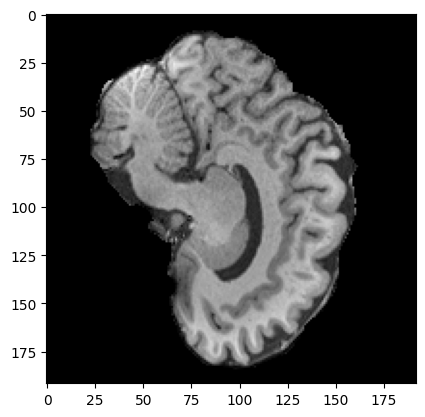

In [36]:
plt.imshow(gt_image[96,:,:,0],cmap='gray')

NameError: name 'lf_gt_seg_dice' is not defined

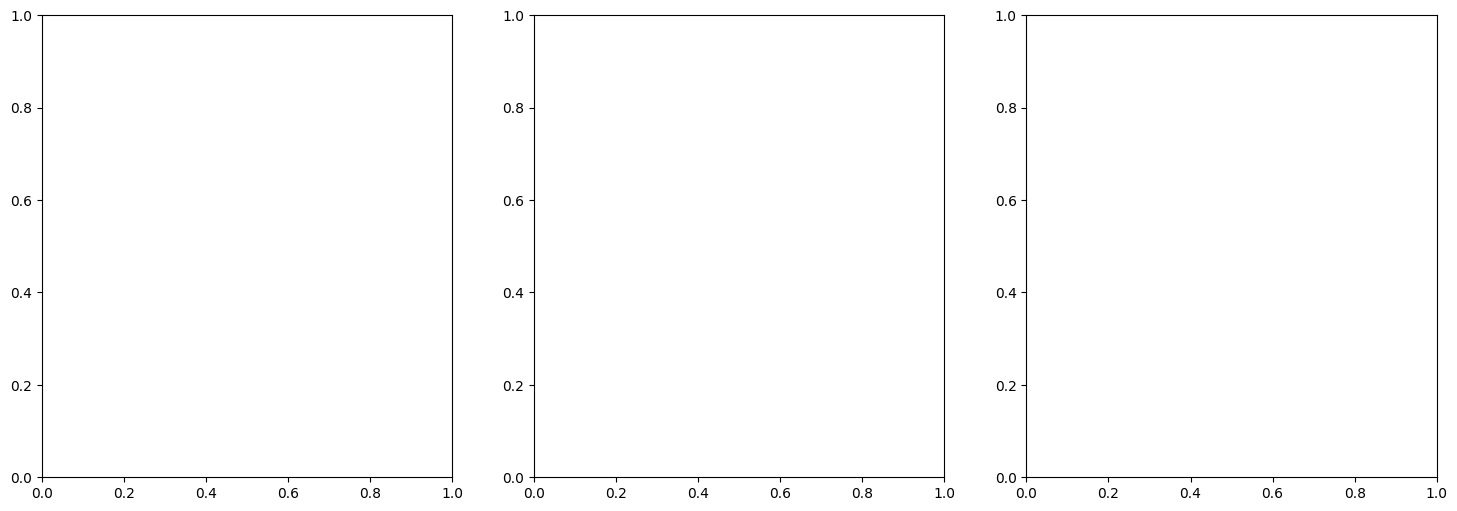

In [42]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
dims = data.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice = data[:, coronal_slice_index, :].T
axes[0].imshow(coronal_slice, cmap='gray')
axes[0].set_title("Coronal View")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Z-axis")
axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice = data[sagittal_slice_index, :, :].T
axes[1].imshow(sagittal_slice, cmap='gray')
axes[1].set_title("Sagittal View")
axes[1].set_xlabel("Y-axis")
axes[1].set_ylabel("Z-axis")
axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice = data[:, :, axial_slice_index].T
axes[2].imshow(axial_slice, cmap='gray')
axes[2].set_title("Axial View")
axes[2].set_xlabel("X-axis")
axes[2].set_ylabel("Y-axis")
axes[2].set_aspect('equal')
axes[2].invert_yaxis()

plt.tight_layout()

plt.show()

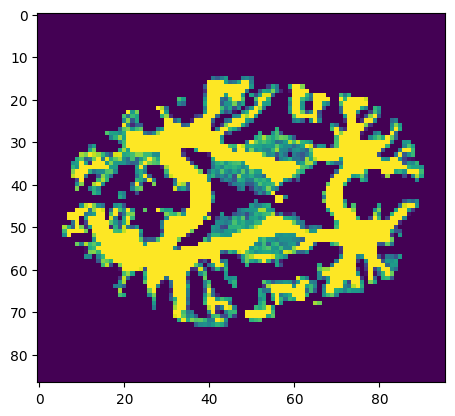

In [60]:
plt.imshow(lf_gt_seg_dice[0,1,:,:,95].detach().cpu())

In [5]:
hf_chunk_size = (96,96,4)
lf_chunk_size = (96//2,96//2,4)
output_image = torch.randn(36864)
output_seg = torch.randn(36864, 4)
output_image_lf = F.interpolate(output_image.unsqueeze(0).unsqueeze(0).squeeze(-1), scale_factor=0.25).squeeze(0)
pred_seg = [(F.interpolate(output_seg[:,i].unsqueeze(0).unsqueeze(0), scale_factor=0.25).squeeze(0).squeeze(0)).reshape(lf_chunk_size) for i in range(output_seg.shape[-1])] #downsampling pred_seg
pred_seg = torch.stack(pred_seg,axis = 0).unsqueeze(0) # shape(1,4 48, 48, 4)
print(output_image_lf.shape, pred_seg.shape)

torch.Size([1, 9216]) torch.Size([1, 4, 48, 48, 4])


In [40]:
# c = output_seg[:,0].reshape(hf_chunk_size) * output_image.reshape(hf_chunk_size)
# print(c.shape, c.permute(2,0,1).unsqueeze(0).shape)
# c = F.interpolate((output_seg[:,0].reshape(hf_chunk_size) * output_image.reshape(hf_chunk_size)).permute(2,0,1).unsqueeze(0), scale_factor=0.5).squeeze(0).permute(1,2,0)
temp = [F.interpolate((output_seg[:,i].reshape(hf_chunk_size) * output_image.reshape(hf_chunk_size)).permute(2,0,1).unsqueeze(0), scale_factor=0.5).squeeze(0).permute(1,2,0) for i in range(output_seg.shape[-1])]
print(temp[1].shape)
# print(c.shape)

torch.Size([48, 48, 4])


In [37]:
import nibabel as nib
img = nib.load('/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/validation_data/Test_Data_T1/preprocessing/brain_extracted/64mT_Test01_T1_brain3.nii.gz').get_fdata()
wm_seg = nib.load('/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/validation_data/Test_Data_T1/preprocessing/brain_extracted/64mT_Test01_T1_brain3_pve_0.nii.gz').get_fdata()

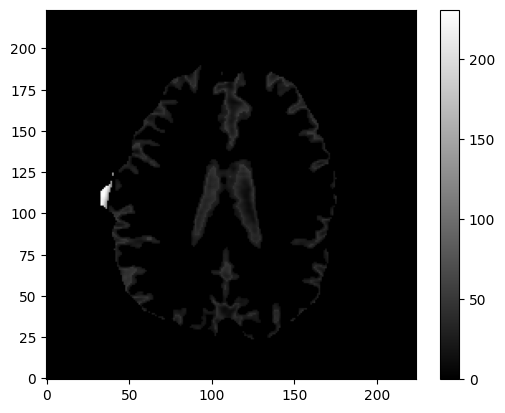

In [39]:
from matplotlib import pyplot as plt
plt.imshow((img*wm_seg)[:,:,90].T,cmap='gray')
# plt.imshow(img[45:48,43:48,95][wm_seg[45:48,43:48,95]>0.9], cmap='gray')
plt.gca().invert_yaxis()
plt.colorbar()

Brightest flat cube starts at: z=32, y=52, x=52


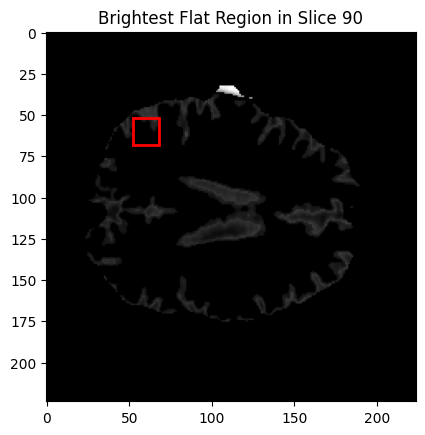

In [44]:
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

def find_brightest_flat_region_3d(img, cube_size=(16, 16, 16), alpha=0.5):
    """
    Find the brightest flat cube (low variance & high intensity) in a 3D MRI image.

    Args:
        img (ndarray): 3D numpy array (MRI volume).
        cube_size (tuple): cube size (dz, dy, dx).
        alpha (float): weight controlling variance penalty.

    Returns:
        (z, y, x): top-left-front coordinates of the cube
        score_map (ndarray): map of scores for visualization
    """
    dz, dy, dx = cube_size
    img = img.astype(np.float32)

    # Compute local mean and variance
    local_mean = uniform_filter(img, size=cube_size)
    local_mean_sq = uniform_filter(img**2, size=cube_size)
    local_var = local_mean_sq - local_mean**2

    # Scoring function: bright but flat
    score = local_mean - alpha * local_var

    # Avoid borders (so cube doesn't exceed image size)
    pad_z, pad_y, pad_x = dz // 2, dy // 2, dx // 2
    score_cropped = score[pad_z:-pad_z, pad_y:-pad_y, pad_x:-pad_x]

    # Find best cube location
    best_loc = np.unravel_index(np.argmax(score_cropped), score_cropped.shape)

    # Adjust to original coordinates
    z, y, x = best_loc[0] + pad_z, best_loc[1] + pad_y, best_loc[2] + pad_x
    return (z, y, x), score


# ---------------- Example Usage ----------------
# Fake MRI volume
img3d = img * wm_seg
img3d[30:40, 50:60, 50:60] += 1.0  # add a bright flat region

# Find brightest flat region
(z, y, x), score = find_brightest_flat_region_3d(img3d, cube_size=(16, 16, 16), alpha=0.5)
print(f"Brightest flat cube starts at: z={z}, y={y}, x={x}")

# Visualize slice
slice_idx = 90
plt.imshow(img3d[:,:,slice_idx], cmap="gray")
rect = plt.Rectangle((x, y), 16, 16, edgecolor='red', facecolor='none', linewidth=2)
plt.gca().add_patch(rect)
plt.title(f"Brightest Flat Region in Slice {slice_idx}")
plt.show()


Loading IXI data

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule
# from LFSynth.ContrastEstimation import forward as contrast_forward
# from LFSynth.ContrastEstimation import read_imgs, tissue_probabilities
import random
from Utils.utils import dice_stack_helper
from Utils.defaults import default_config
from Utils.utils import get_device, norm
import sys
from PIL import Image
from Data.ImagePreparation import ImagePreparation

In [ ]:
from matplotlib import pyplot as plt
slice_num = 90 #default_config["slice"]
# /Data/ixi/T1/102/registration/fast_restore.nii.gz
dataset_num = 102
hf_loc = "./Data/ixi/T1/" + str(dataset_num)+ "/fast_restore.nii.gz"
hf_observed = nib.load(hf_loc).get_fdata()
plt.imshow(hf_observed[:,:,slice_num])

In [ ]:
(wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like), (wm_prob, gm_prob, csf_prob, bg_prob), (wm_snr, gm_snr, csf_snr), M = contrast_forward(dataset_num) #Generating ULF GT

(91, 109, 182)


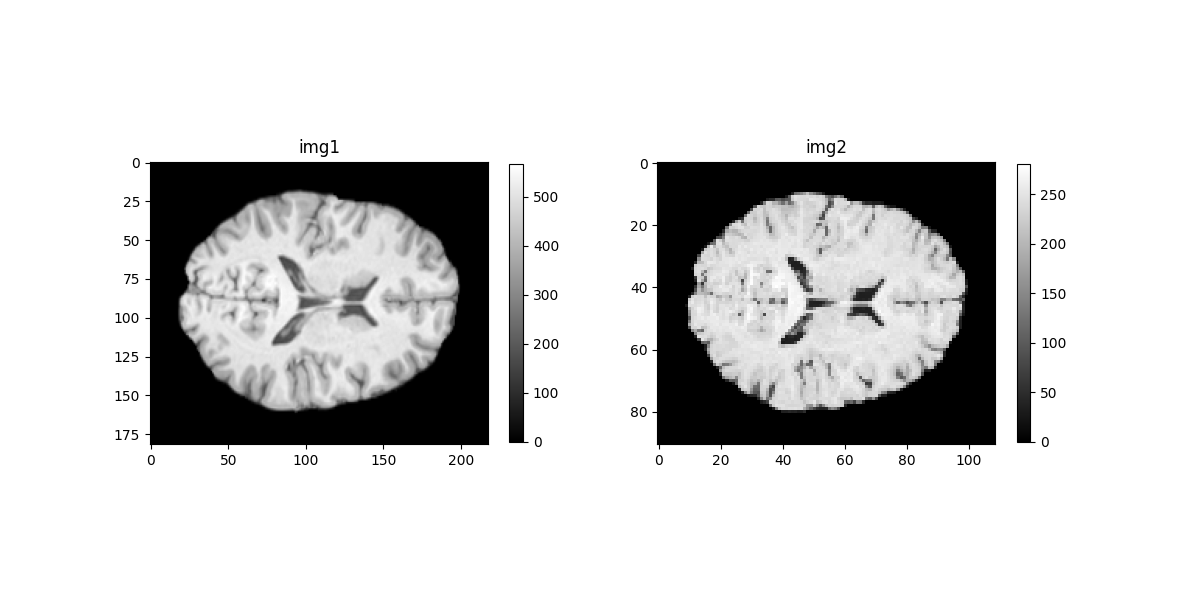

In [23]:
# %matplotlib inline
%matplotlib ipympl
from Utils.plotting_utils import plot_2_images
import numpy as np
# lf_like[lf_like<10] = 0
bg_masked_lf = np.where(lf_like<25, 0, lf_like)
print(bg_masked_lf.shape)
fig = plot_2_images(hf_observed[:,:,slice_num], bg_masked_lf[:,:,slice_num], title1="img1", title2="img2")

In [25]:
import numpy as np
ulf_nib = nib.Nifti1Image(bg_masked_lf, np.eye(4))
nib.save(ulf_nib, '/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/ulf_test/ulf.nii.gz')

In [6]:
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule
# from LFSynth.ContrastEstimation import forward as contrast_forward
# from LFSynth.ContrastEstimation import read_imgs, tissue_probabilities
import random
from Utils.utils import dice_stack_helper
from Utils.defaults import default_config
from Utils.utils import get_device, norm
import sys
from PIL import Image
from Data.ImagePreparation import ImagePreparation
from Data.load_ixi import load_data, get_hf_observed_segmentations
import copy
config = copy.deepcopy(default_config)
config["is_new_contrast"] = False

hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_data(102, config) #uncomment

delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


SNR matrix: [[ 156.97948867 -115.97973942    0.        ]
 [ 156.97948867    0.          -54.0705368 ]
 [   0.          115.97973942  -54.0705368 ]] Target Contrast:  [10.62876391 36.76892224 26.14015833]


delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Solution :  [0.37500575 0.41592995 0.40871221]
Target Contrast:  [10.62876391 36.76892224 26.14015833] Achieved contrast:  [10.62876389 36.76892243 26.14015854]


In [4]:
config = copy.deepcopy(default_config)
config["in_features"] = 3
config["l1"] = 100 #mse
config["l3"] = 20 #seg
config["l4"] = 0.1 #tv_img
config["l5"] = 0.1 #tv_seg

hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_data(102, config) #uncomment
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)
lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
# print("gt_image: ", gt_image.shape, "lf_gt: ", lf_gt.shape, "lf_gt_seg_dice: ", lf_gt_seg_dice.shape)
print('gt_image, lf_gt loaded')


dataset = RandomPointsDataset(gt_image, lf_gt, lf_gt_seg_dice, points_num=POINTS_PER_SAMPLE)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=False) # We set a batch_size of 1 since our dataloader is already returning a batch of points.


Device =  mps
known_m =  [0.5 0.6 0.2]
[[ 63.63398992   0.         -24.1076862 ]
 [ 63.63398992 -50.15986627   0.        ]
 [  0.          50.15986627 -24.1076862 ]] [26.99545772  1.7210752  25.27438252]


delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.


             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [522.5012678952976, 522.5012456913062, 522.501...   
1   [522.5015678952976, 522.501545691336, 522.5015...   
2   [522.5027678952976, 522.5027456914552, 522.502...   
3   [522.5042678952976, 522.5042456916042, 522.504...   
4   [522.5072678952976, 522.5072456919022, 522.507...   
..                                                ...   
59  [113.81851938738929, 113.81851728732131, 113.8...   
60  [113.89351938738929, 113.89351728881144, 113.8...   
61  [113.96851938738928, 113.96851729030155, 113.9...   
62  [114.04351938738928, 114.04351729179167, 


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


(91, 109, 182) (91, 109, 182) (182, 218, 182) 63.633989918981285 [0.48891551 0.58593795 0.17074167]
torch.Size([1, 1805258]) torch.Size([1, 4, 91, 109, 182])
gt_image, lf_gt loaded


NameError: name 'RandomPointsDataset' is not defined

In [7]:
hf_ground_truth.shape, lf_gt.shape

((182, 218, 182), torch.Size([91, 109, 182, 1]))

In [3]:
import ast
file_path = './Data/validation_data/sub_0011/hf/snrs.txt'
lines = []
try:
    with open(file_path, 'r') as file:
        for line in file:
            lines.append(ast.literal_eval(((line.strip()).split(' ', 1)[1])))
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [4]:
lines

[[60, 41, 10, 7],
 [23, 75, 4, 4],
 [48, 46, 3, 4],
 [9, 90, 5, 5],
 366.56536430782995,
 303.80354256414984,
 141.97121209109136]

In [5]:
lines[:4]

[[60, 41, 10, 7], [23, 75, 4, 4], [48, 46, 3, 4], [9, 90, 5, 5]]

In [6]:
lines[4:]

[366.56536430782995, 303.80354256414984, 141.97121209109136]

Sensitivity Tests

In [13]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
# from nilearn import image
# from nilearn import plotting
# from tkinter import filedialog as fd
from scipy.ndimage import gaussian_filter
import math
from scipy import optimize, stats
from scipy.optimize import NonlinearConstraint, LinearConstraint, minimize, Bounds, least_squares
import itertools
from sklearn.metrics import mean_squared_error
import matplotlib.patches as patches
import pandas as pd 
from fsl.wrappers.fast import fast as fast
import time
import ast

from LFSynth.ContrastEstimation import read_imgs, get_hf_tissue_seg, seg_to_intenities, calc_hf_snr, toy_values, GridSearch, add_rician, recombine

In [ ]:
dataset_num = 102
folder = './Data/ixi/T1/' + str(dataset_num) + "/"
(img_nib, wm_nib, gm_nib, csf_nib) = read_imgs(folder)
(wm_seg, gm_seg, csf_seg, bg_seg) = get_hf_tissue_seg(wm_nib, gm_nib, csf_nib)
(wm, gm, csf, bg, hf) = seg_to_intenities(img_nib, wm_nib, gm_nib, csf_nib, bg_seg)
(wm_snr, gm_snr, csf_snr) = calc_hf_snr(img_nib, wm_nib, gm_nib, csf_nib, dataset_num)


In [15]:

class GridSearch :
  
  def __init__(self, s, c, upper_bound=1.0):
    self.param_m = [0.1, 0.15, 0.2, 0.25 , 0.3, 0.35 , 0.4, 0.5] #init M search space
    # self.param_m = [0.1, 0.2, 0.3, 0.4, 0.5]
    self.param_epsilon =  [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] #regularization_strength search space
    self.solver = 'trust-constr'
    # self.limits = Bounds(0,1)
    self.limits = Bounds(0, upper_bound)
    self.losses = []
    self.results = {}
    self.results["m_init"] = []
    self.results["epsilon"] = []
    self.results["loss"] = []
    self.results["res"] = []
    self.s = s
    self.c = c


  def obj_function(self,m):
    loss = 0.5 * np.sum(((self.s@m) - self.c)**2)
    reg = (np.sum(m**2))
    # print(loss,reg)
    total_loss = loss + (self.epsilon * reg)
    self.losses.append(total_loss)
    return total_loss
  
  def easy_results(self, grid_results):
    grid_results["niter"] = []
    grid_results["x"] = []
    grid_results["cost"] = []

    for i in range(len(grid_results["res"])):
        res_obj = grid_results["res"][i]
        grid_results["niter"].append(res_obj.niter)
        grid_results["x"].append(res_obj.x)
        grid_results["cost"].append(res_obj.fun)
    df = pd.DataFrame.from_dict(grid_results)
    return df
  
  def solve(self):
    for i in self.param_m:
      for j in self.param_epsilon:
        self.m = np.ones(self.c.shape[0]) * i
        self.epsilon = j
        self.losses = []
        # print("Before optim", self.m)
        self.res = minimize(self.obj_function, self.m, bounds=self.limits, method=self.solver,)
        # print("After optim", self.res.x)
        self.results["m_init"].append(self.m)
        self.results["epsilon"].append(self.epsilon)
        self.results["loss"].append(self.losses)
        self.results["res"].append(self.res)
        
    return self.results
  
  def select_solution(self, grid_results):
    '''
    - Selects the 'best' solution from the subset of optimal solutions. This constraint is important as sometimes solver can find solutions where the multipliers are on different scales. 
    - Alternatively, 'best' solution can also be handpicked from the optimal subset


    Takes the grid results dataframe as input 
    Creates a temporary dataframe to filter the solutions based on minimal cost function and order of magnitude of solutions to be on same scale. 
    Returns the solution list (vector) : M
    '''
    temp_df = grid_results[grid_results['cost']<grid_results['cost'].min()+0.01]
    temp_df["log_constraint"] = " "

    for index in range(len(temp_df)):
        diff = abs(np.abs(np.floor(np.log10(((temp_df['x']).values[index][0])))) - np.abs(np.floor(np.log10(((temp_df['x']).values[index][1]))))) + abs(np.abs(np.floor(np.log10(((temp_df['x']).values[index][0])))) - np.abs(np.floor(np.log10(((temp_df['x']).values[index][2]))))) + abs(np.abs(np.floor(np.log10(((temp_df['x']).values[index][1])))) - np.abs(np.floor(np.log10(((temp_df['x']).values[index][2])))))
        temp_df['log_constraint'].values[index] = diff
    if(len(temp_df[temp_df['log_constraint']<1]) > 0):
        M = temp_df[temp_df['log_constraint']<1][temp_df[temp_df['log_constraint']<1]['cost']==temp_df[temp_df['log_constraint']<1]['cost'].min()]["x"].tolist()[0]
    else:
        #In case all the found solutions have different orders of magnitude, choose the minimal cost func. (Undesired case)
        M = grid_results[grid_results['log_constraint']==grid_results['log_constraint'].min()]["x"].tolist()[0]
    return M

In [46]:
import ast
def get_rois(dataset_num='0011', field_type='hf'):
    folder = './Data/ixi/T1/' + str(dataset_num) +  '/' + field_type
    file_path =  folder + '/snrs.txt'
    lines = []
    try:
        with open(file_path, 'r') as file:
            for line in file:
                lines.append(ast.literal_eval(((line.strip()).split(' ', 1)[1])))
                
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    roi_voxels = lines[:4]
    roi_snrs = lines[4:]
    return roi_voxels, roi_snrs

def get_m(dataset_num='0011', target_type='hf'):
    #m^{ULF} = get_m (c^{HF}, S^{ULF}) i.e., if target_type == ULF then S matrix should be from HF and if target_type == HF then S matrix should be ULF ;
    if(target_type == 'ulf'):
        S_type = 'hf'
        upper_bound = 1.0
    else:
        S_type = 'ulf'
        upper_bound = np.inf
    rayleigh_correction = 1.53
    _, S_list = get_rois(dataset_num, field_type=S_type)
    print("S list", S_list)
    s = np.array([[S_list[0], -S_list[1], 0], [S_list[0], 0, -S_list[2]], [0, S_list[1], -S_list[2]]]) #SNR matrix #S_list[0] = WM, S_list[1] = GM, S_list[2] = CSF
    # target_c = get_target_c(dataset_num, target_type)
    # target_c = np.array([19.59, 74.456, 54.86])
    target_c = np.array([8, 25,  17])
    grid = GridSearch(s,target_c, upper_bound=upper_bound)
    grid_results = grid.solve()
    grid_results = grid.easy_results(grid_results)
    # print(grid_results)
    M = grid.select_solution(grid_results)
    
    # M = grid_results.iloc[0].x
    return s, target_c, M



S list [156.97948867261618, 115.97973942270487, 54.0705368046849]


delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Solution :  [0.22705386 0.23834162 0.19683176]
Target Contrast:  [ 8 25 17] Achieved contrast:  [ 7.9999998  25.00000006 17.00000025]


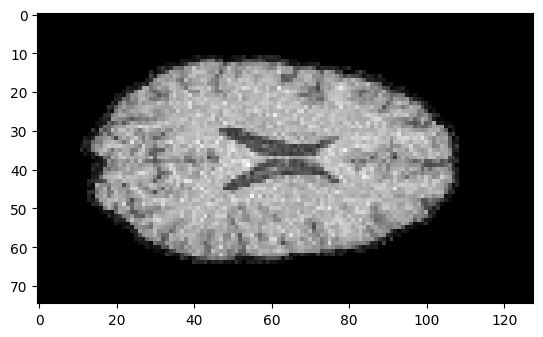

In [47]:
s, target_c, M = get_m('102', target_type='ulf')

print("Solution : ", M)
print("Target Contrast: " , target_c, "Achieved contrast: ", s@M)
(wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like) = recombine(wm, gm, csf, bg, M)

mask = np.where(lf_like>0 ,1.0, 0.0)
rician_noise = add_rician(lf_like.shape, v = 5, s = 15)
ulf_temp = lf_like + (rician_noise * mask) #adding rician noise only to foreground voxels
plt.imshow(ulf_temp[:,:,175],  cmap='gray')
plt.show()

In [10]:
#Get Target Contrasts
'''
SNR_WM = 70.39895521535809
SNR_GM = 55.26709186683596
SNR_CSF = 12.447588313007502


cwg = SNR_WM - SNR_GM
cwc = SNR_WM - SNR_CSF
cgc = SNR_GM - SNR_CSF
print("Contrasts -> cwg: ", cwg, "cwc: ", cwc, "cgc: ", cgc)
print(cwg,  cwc, cgc)
'''

Contrasts -> cwg:  15.131863348522124 cwc:  57.951366902350586 cgc:  42.81950355382846
15.131863348522124 57.951366902350586 42.81950355382846


In [17]:
def plot_2_images(img1, img2, title1="img1", title2="img2", ):
    fig, axes = plt.subplots(1,2, figsize=(12,6))
    im1 = axes[0].imshow(img1, cmap = 'gray')
    axes[0].set_title(title1)
    fig.colorbar(im1, shrink = 0.6)
    im2 = axes[1].imshow(img2, cmap = 'gray')
    axes[1].set_title(title2)
    fig.colorbar(im2,  shrink = 0.6)
    # plt.show(block=False)
    return fig

def downsample(img,sigma = 0.4):
    smooth_anat_img = gaussian_filter(img, sigma,mode='nearest')
    downsampled = smooth_anat_img[::2, ::2,:]
    return downsampled
    
def recombine(wm, gm, csf, bg, M):
    #Downsample, Contrast Modulation and Recombination on downsampled tissues
    
    csf_new = M[2] * downsample(csf)
    gm_new = M[1] * downsample(gm)
    wm_new = M[0] * downsample(wm)
    

    bg_new = downsample(bg)
    lf_img = csf_new + gm_new + wm_new + bg_new
    return wm_new, gm_new, csf_new, bg_new, lf_img


In [48]:

s, target_c, M = get_m('102', target_type='ulf')
print("Solution : ", M)
print("Target Contrast: " , target_c, "Achieved contrast: ", s@M)
(wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like) = recombine(wm, gm, csf, bg, M)
# lf_like = lf_like + np.random.normal(2, 0.75, size=lf_like.shape) #adding gaussian noise
# lf_like = lf_like + add_rician(lf_like.shape, v = 5, s = 10) #adding rician noise

S list [156.97948867261618, 115.97973942270487, 54.0705368046849]


delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Solution :  [0.22705386 0.23834162 0.19683176]
Target Contrast:  [ 8 25 17] Achieved contrast:  [ 7.9999998  25.00000006 17.00000025]


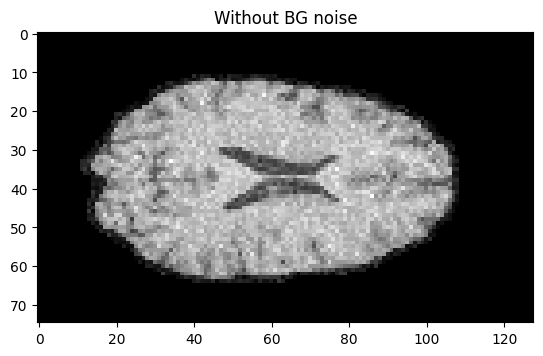

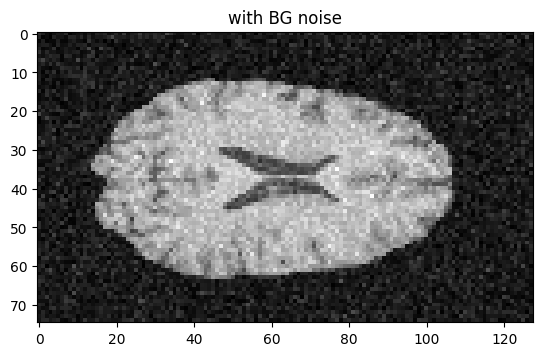

In [49]:
mask = np.where(lf_like>0 ,1.0, 0.0)
rician_noise = add_rician(lf_like.shape, v = 5, s = 15)
ulf_temp = lf_like + (rician_noise * mask) #adding rician noise only to foreground voxels
plt.imshow(ulf_temp[:,:,175],  cmap='gray')
plt.title("Without BG noise")
plt.show()
final_ulf = lf_like + (rician_noise) #addiing rician noise
plt.imshow(final_ulf[:,:,175],  cmap='gray')
plt.title("with BG noise")
plt.show()

In [50]:
from fsl.wrappers.fast import fast as fast
ulf_temp_nib = nib.Nifti1Image(ulf_temp, np.eye(4)) #without bg noise
nib.save(ulf_temp_nib, './Data/ixi/T1/102/sensitivity_data/temp/brain.nii.gz')
# fast('./Data/ixi/T1/102/sensitivity_data/temp/' + 'brain.nii.gz', out= './Data/ixi/T1/102/sensitivity_data/temp/' + 'fast', g= False, b = True , B = True, n_classes=3, t=1)
# print("Segmentation done.....")

# ulf_nib = nib.Nifti1Image(final_ulf, np.eye(4)) #with bg noise
# nib.save(ulf_nib, './Data/ixi/T1/102/sensitivity_data/temp/brain_final.nii.gz')

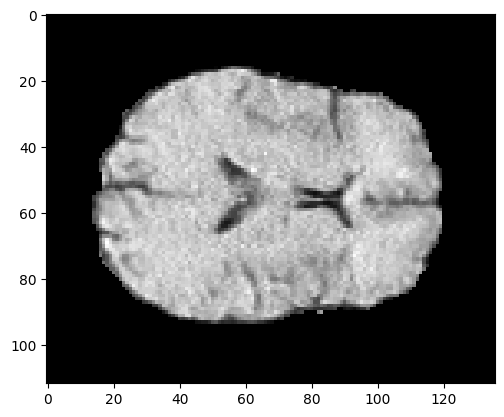

In [47]:
real_ulf = nib.load('./Data/validation_data/sub_0023/ulf/fast_restore.nii.gz').get_fdata()
plt.imshow(real_ulf[:,:,19], cmap='gray')

In [45]:
real_ulf.shape

(112, 136, 40)